# 04 - Feature Diagnostics

Goal: sanity-check the early-window features built in `03_feature_engineering.ipynb`
before trusting a model's use of them -- distributions, correlations, separation
by severity_class, and whether early-feature space shows any natural clustering
that lines up with severity_class.


In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from flashpoint.db import get_connection

DB_PATH = Path("../data/flashpoint.duckdb")
con = get_connection(DB_PATH)

full_df = con.execute("""
    SELECT f.*, o.max_area_ha, o.severity_class
    FROM early_features f
    JOIN event_outcomes o ON o.event_id = f.event_id
""").df()
print(f"{len(full_df)} events with early features + outcomes")


607 events with early features + outcomes


## Step 1: Early feature distributions

One histogram per feature -- worth a quick look for anything oddly-shaped
(bimodal, heavily skewed, suspicious spikes at a boundary value) before
trusting a model's use of it.

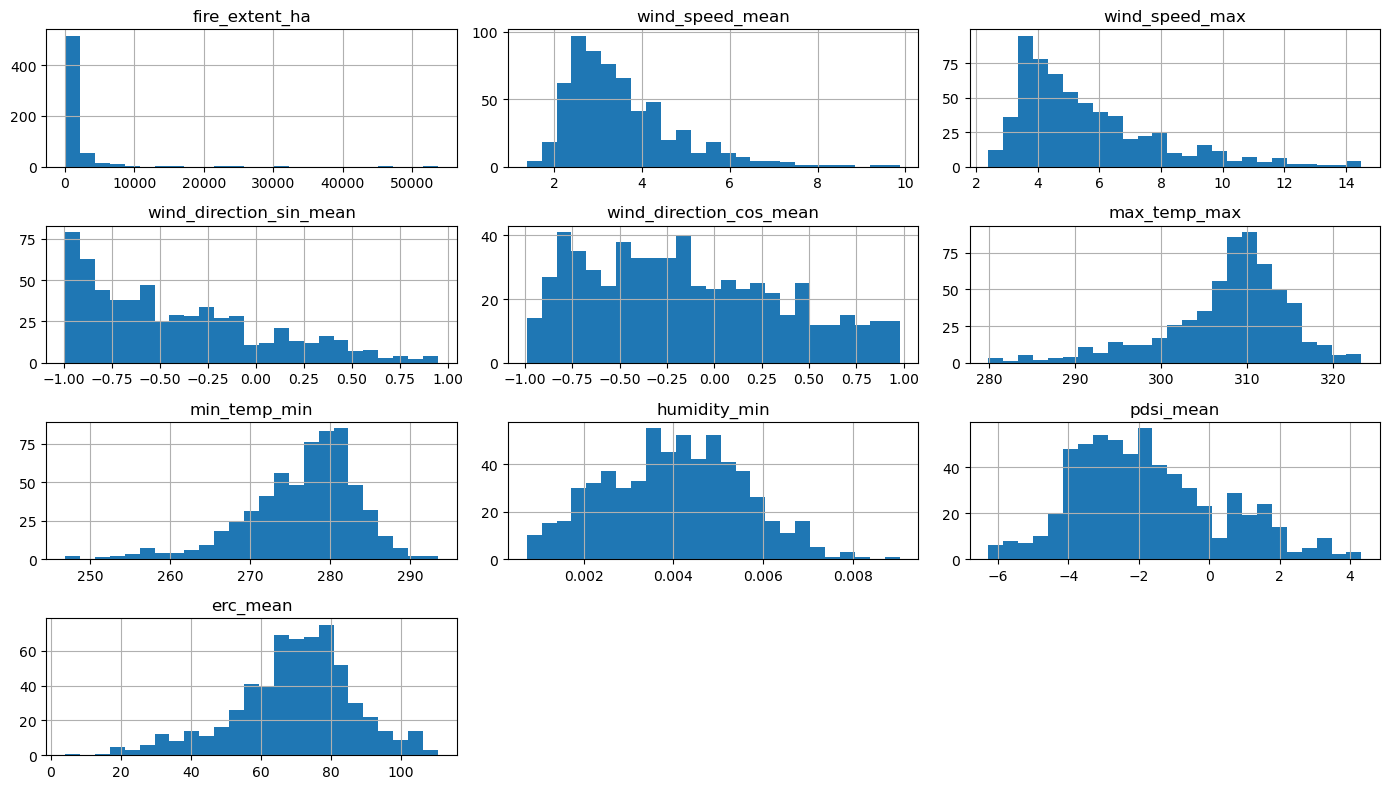

In [2]:
FEATURE_COLS = [
    "fire_extent_ha", "wind_speed_mean", "wind_speed_max",
    "wind_direction_sin_mean", "wind_direction_cos_mean",
    "max_temp_max", "min_temp_min", "humidity_min", "pdsi_mean", "erc_mean",
]

full_df[FEATURE_COLS].hist(figsize=(14, 8), bins=25)
plt.tight_layout()

## Step 2: Feature correlations

Worth checking before trusting SHAP rankings too literally -- if two
features are highly correlated, SHAP can split "credit" between them in
ways that make either look less important than the pair really is.

Text(0.5, 1.0, 'Early feature correlation matrix')

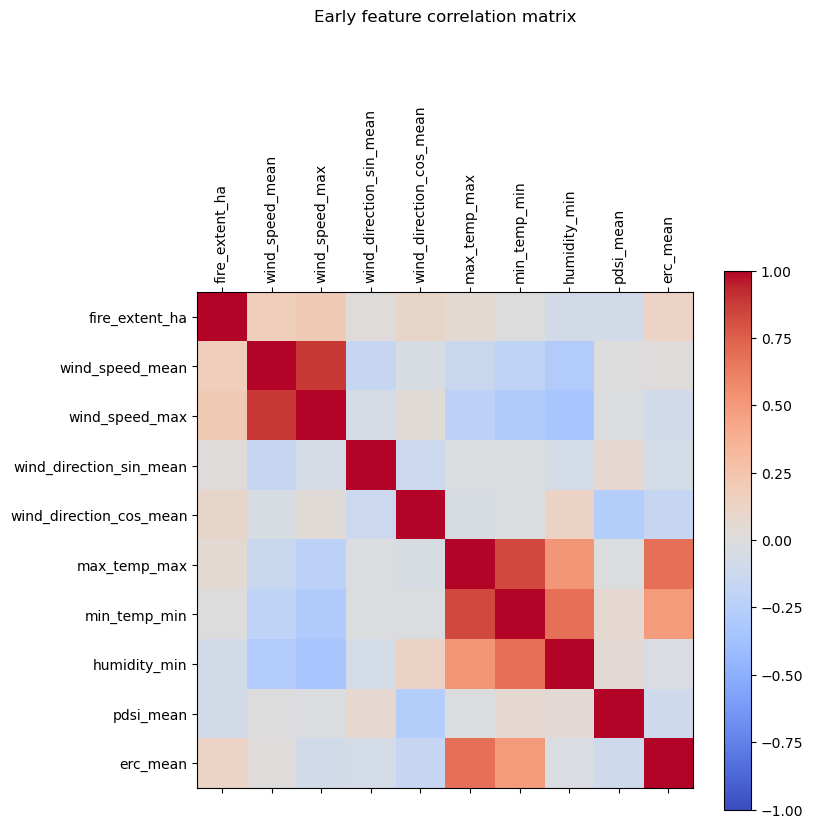

In [3]:
corr = full_df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90)
ax.set_yticklabels(FEATURE_COLS)
plt.colorbar(im)
plt.title('Early feature correlation matrix', pad=60)

## Step 3: Do features separate by severity class at all?

Boxplots of each feature, split by severity_class -- a visual gut check
for whether the classes are separable BEFORE trusting a model's accuracy
number to tell you that story.

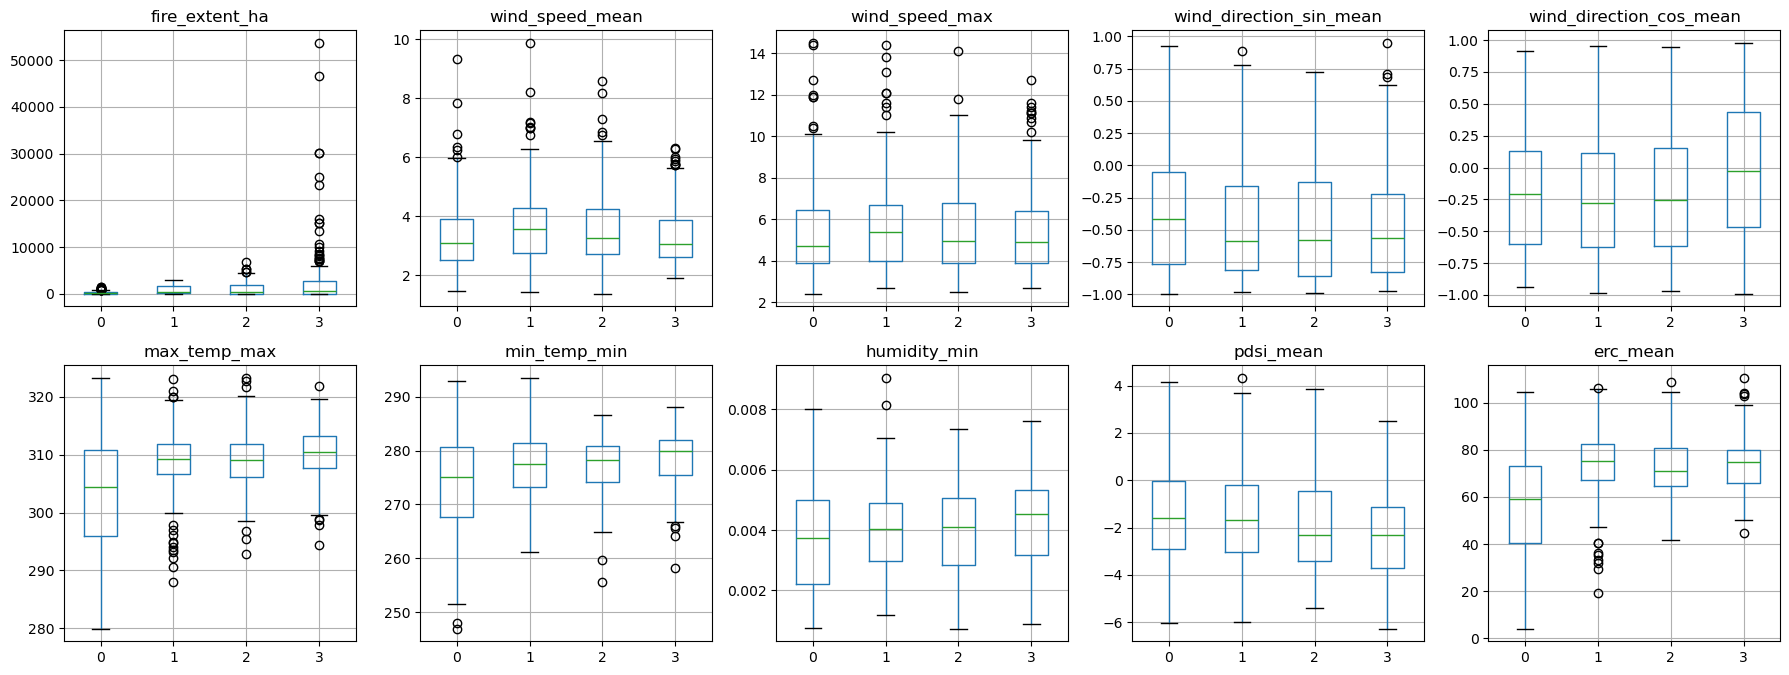

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, FEATURE_COLS):
    full_df.boxplot(column=col, by='severity_class', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()

## Step 4: Natural clusters in early-feature space

PCA down to 2D + KMeans, purely exploratory -- do events form natural
groupings in early-feature space at all, and if so, do those groupings
line up with severity_class (colored) or cut across it?

Explained variance (2 PCs): 0.48


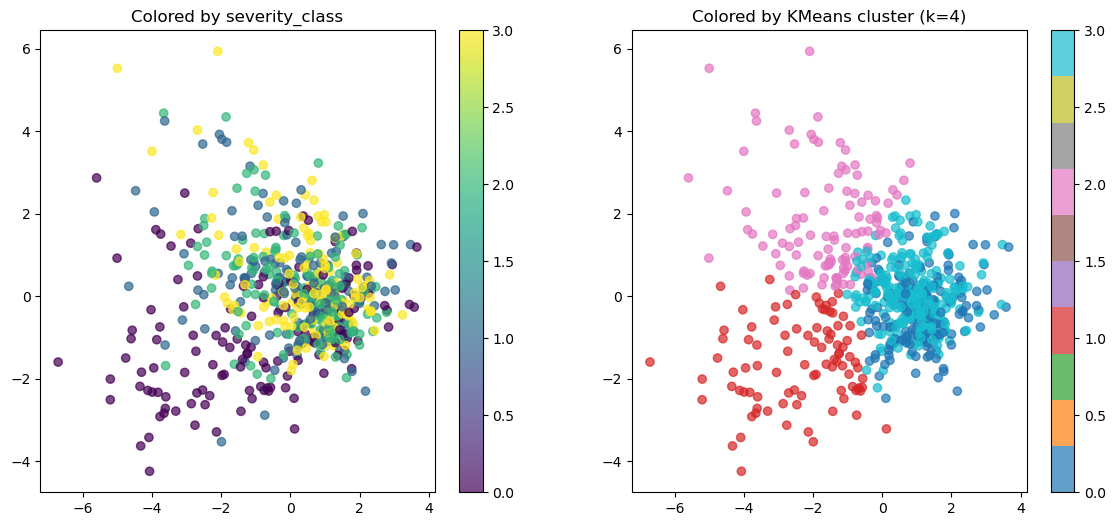

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

X = StandardScaler().fit_transform(full_df[FEATURE_COLS])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"Explained variance (2 PCs): {pca.explained_variance_ratio_.sum():.2f}")

kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=full_df['severity_class'], cmap='viridis', alpha=0.7)
axes[0].set_title('Colored by severity_class')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
axes[1].set_title('Colored by KMeans cluster (k=4)')
plt.colorbar(sc1, ax=axes[1])

## Step 5: Takeaways

- Any features that look bimodal/suspicious in their raw distribution?
- Any pair of features highly correlated enough to reconsider dropping one?
- Do the boxplots show ANY visual separation by severity_class, even where
  accuracy is modest -- that would support "real but weak signal" over
  "no signal at all"
- Do PCA/KMeans clusters cut across severity_class (suggesting the natural
  groupings in the data are about something else, e.g. region or season) or
  align with it?


In [6]:
con.close()